# Чтение листов


Методом пристального взгляда, можно заметить, что в предпоследнем (скрытом) листе находится две таблицы:
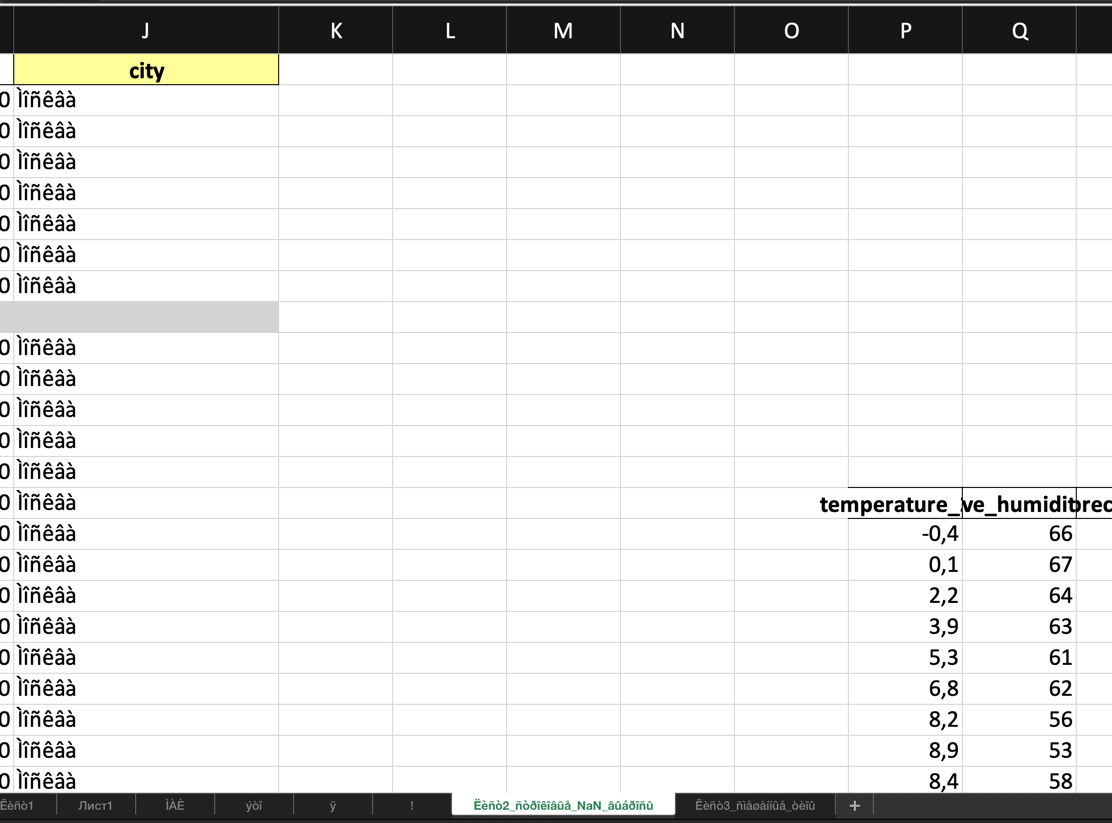


Самое простое решение здесь – ручками создать новый лист с этой таблицей:
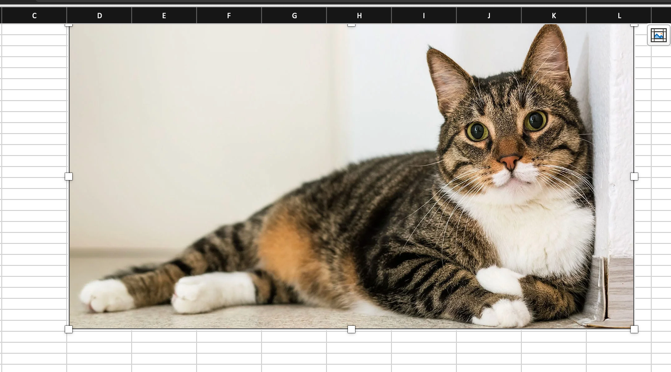
...Муся, это ты?


**Результат:** вторая таблица из предпоследнего листа перемещена в Лист4 (теперь самый последний)

Также можно заметить проблемы с кодированием текста – см. файл [`utils`](./utils.py) (там решение)
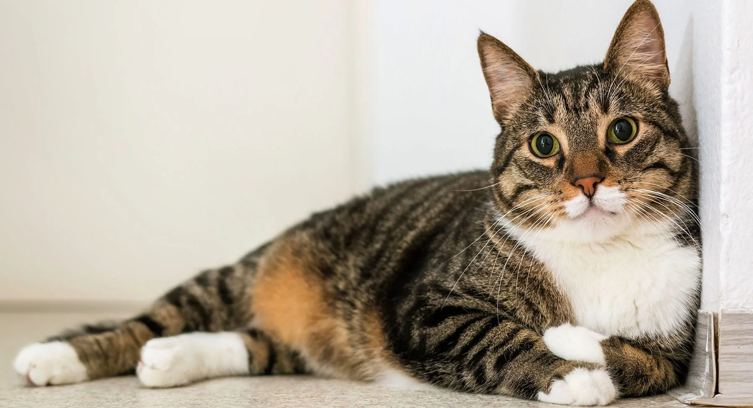
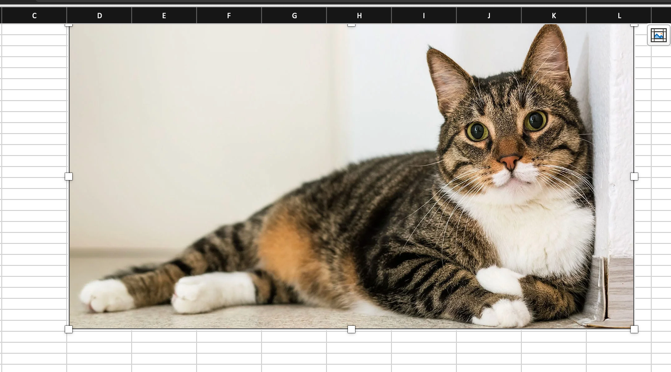
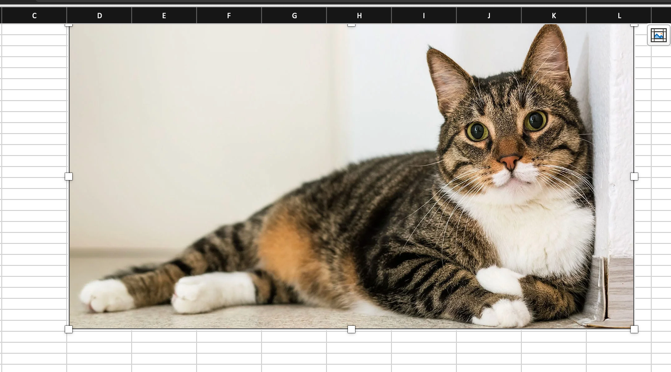

In [1]:
import warnings

import matplotlib.pyplot as plt  #visualisation
import numpy as np
import pandas as pd

from lab2.utils import decode_win

warnings.filterwarnings('ignore')

xlsx_path = "have_fun.xlsx"

xls = pd.ExcelFile(xlsx_path)

dfs = {}

for i, sheet_name in enumerate(xls.sheet_names):
    df = pd.read_excel(xlsx_path, sheet_name=sheet_name)

    if not df.empty:
        dfs[decode_win(sheet_name)] = df

print("Загруженные листы:", ", ".join(dfs.keys()))


Загруженные листы: Лист1, Лист2_строковые_NaN_выбросы, Лист3_смешанные_типы, Лист4


# Чистка dfs

In [2]:
from lab2.utils import get_clean_df

cleaned_dfs = [get_clean_df(df) for df in dfs.values()]

# Объединяем всё в один dataframe + избавляемся от дубликатов
df = pd.concat(cleaned_dfs, ignore_index=True).drop_duplicates(subset=['ds', 'city'])

get_clean_df – функция из utils: чинит кодировку в city +(резолвит захардоженное название =)), правильно работает с числами, обрабатывает невалидные значения (`errors='coerce'`), удаляет строки без дат, приводит всё к pd типам

> Про захардкоженное название: некоторые города названы с опечаткой

In [3]:
from lab2.utils import interpolate_time_by_group

df = df.sort_values(by=['city', 'ds'])
# Заполняем пропуски интерполяцией (отдельно по городам)
df = df.groupby('city', group_keys=False).apply(interpolate_time_by_group)

print(df.info())
print(df['city'].unique())
display(df.head())
display(df.describe(include='all'))

<class 'pandas.DataFrame'>
Index: 368207 entries, 0 to 61367
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   ds                    368207 non-null  datetime64[us]
 1   temperature_2m        368207 non-null  float64       
 2   relative_humidity_2m  368207 non-null  float64       
 3   precipitation         368207 non-null  float64       
 4   rain                  368207 non-null  float64       
 5   snowfall              368207 non-null  float64       
 6   weathercode           368207 non-null  float64       
 7   wind_speed_10m        368207 non-null  float64       
 8   surface_pressure      368207 non-null  float64       
 9   city                  368207 non-null  str           
dtypes: datetime64[us](1), float64(8), str(1)
memory usage: 30.9 MB
None
<StringArray>
['Благовещенск', 'Геленджик', 'Москва', 'Находка', 'Санкт-Петербург', 'Сочи']
Length: 6, dtype: str


,ds,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,city
0,2019-01-01 00:00:00,-13.7,56.0,0.0,0.0,0.0,3.0,12.600000,1008.700012,Благовещенск
1,2019-01-01 01:00:00,-13.2,56.0,0.0,0.0,0.0,3.0,16.299999,1008.500000,Благовещенск
2,2019-01-01 02:00:00,-12.5,56.0,0.0,0.0,0.0,3.0,18.000000,1008.299988,Благовещенск
3,2019-01-01 03:00:00,-12.1,56.0,0.0,0.0,0.0,3.0,18.100000,1007.900024,Благовещенск
4,2019-01-01 04:00:00,-11.9,56.0,0.0,0.0,0.0,3.0,17.600000,1007.500000,Благовещенск


,ds,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,city
count,368207,368207.000000,368207.000000,368207.000000,368207.000000,368207.000000,368207.000000,368207.000000,368207.000000,368207
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Благовещенск
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61368
mean,2022-07-02 11:25:00.004074,8.728458,74.028872,1.363859,0.093304,0.008112,11.137726,12.103400,1006.874987,NaN
min,2019-01-01 00:00:00,-49.990098,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,800.185777,NaN
25%,2020-10-01 05:30:00,1.000000,63.000000,0.000000,0.000000,0.000000,0.000000,6.700000,998.099976,NaN
50%,2022-07-02 11:00:00,10.000000,78.000000,0.000000,0.000000,0.000000,3.000000,10.500000,1009.099976,NaN
75%,2024-04-01 17:00:00,17.900000,89.000000,0.000000,0.000000,0.000000,3.000000,15.600000,1016.099976,NaN
max,2025-12-31 23:00:00,79.974214,100.000000,998.260221,27.100000,4.620000,75.000000,249.928074,1199.037397,NaN


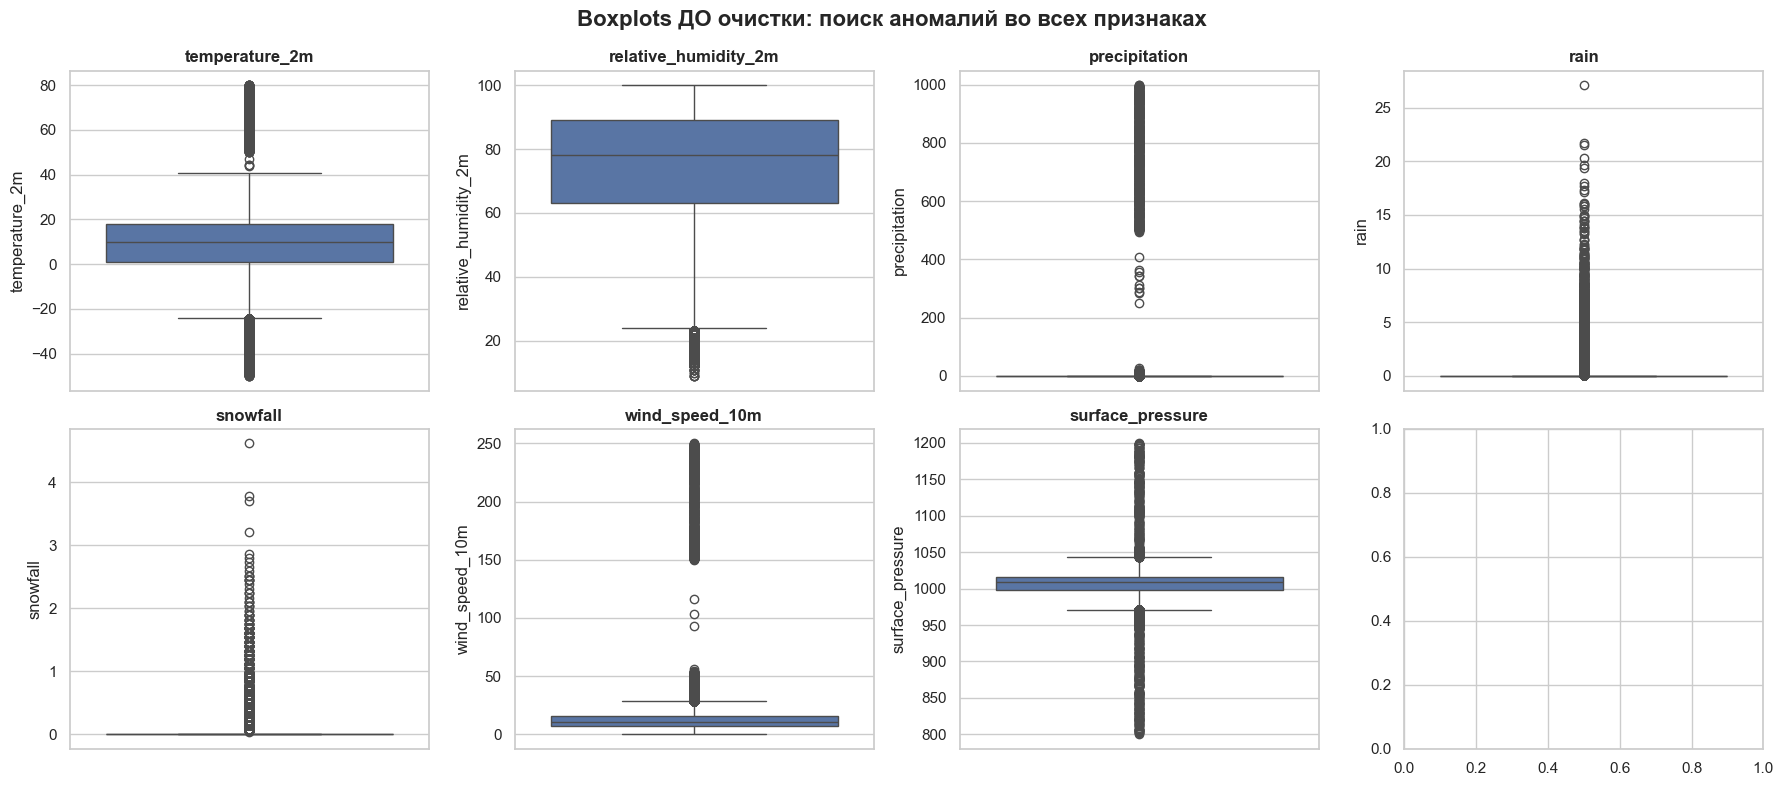

In [4]:
import seaborn as sns  #visualisation

sns.set_theme(style="whitegrid")

numeric_features = [
    'temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain',
    'snowfall', 'wind_speed_10m', 'surface_pressure'
]


def boxplots(title):
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    for col, ax in zip(numeric_features, axes.flatten()):
        sns.boxplot(y=df.reset_index(drop=True)[col], ax=ax)
        ax.set_title(col, fontweight='bold')

    plt.tight_layout()
    plt.show()


boxplots('Boxplots ДО очистки: поиск аномалий во всех признаках')

Удалено строк: 27844. Осталось: 340363


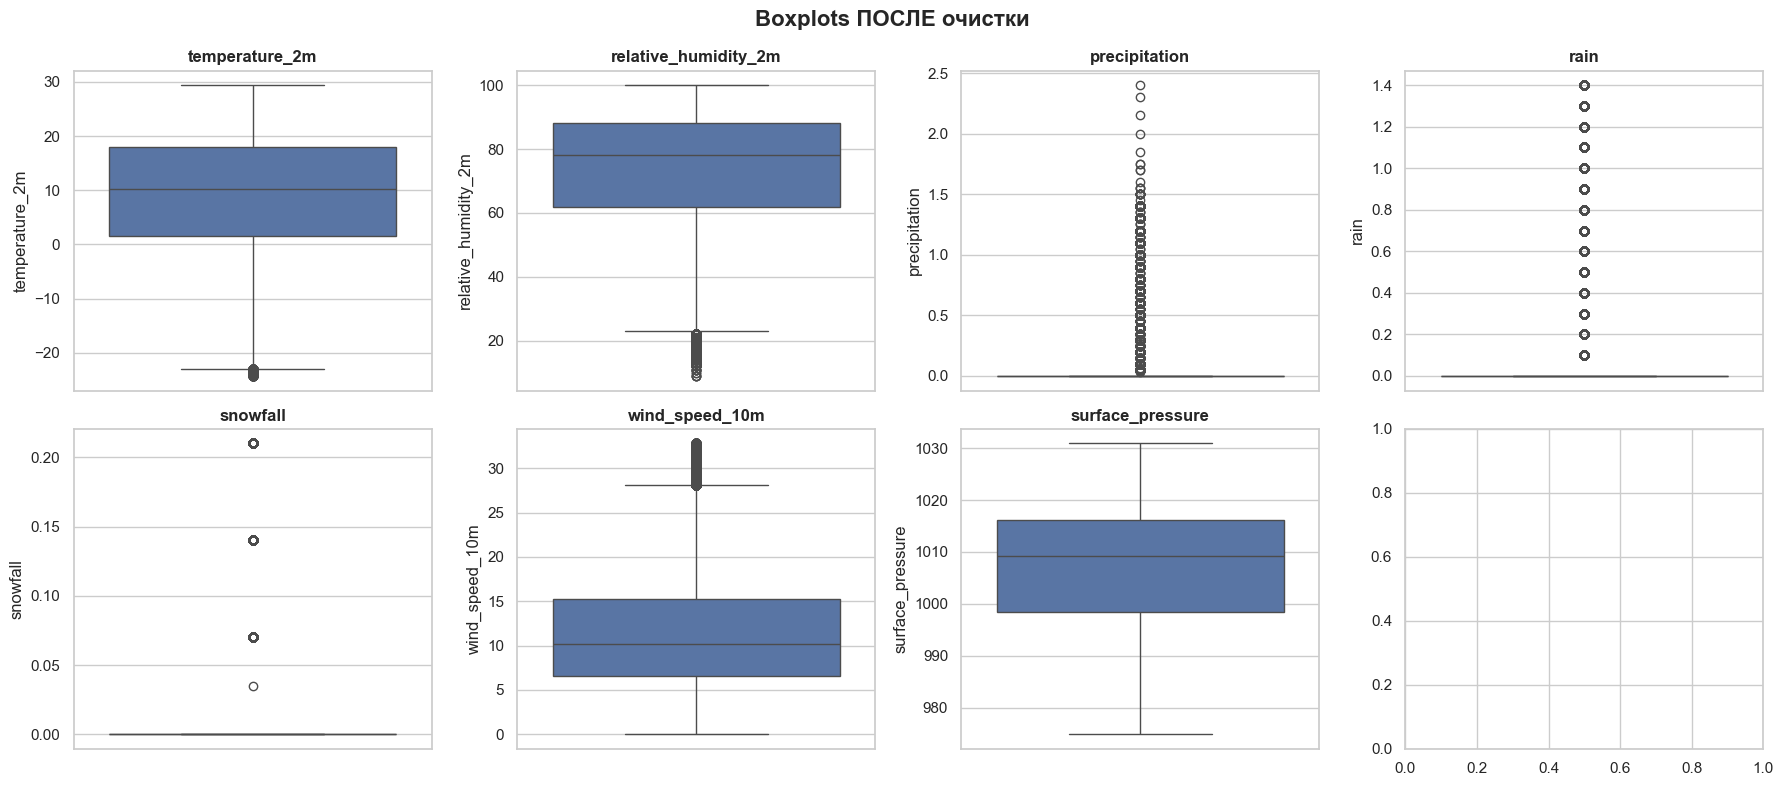

In [5]:
before_clean_len = len(df)

# temperatura filter
df = df[(df['temperature_2m'] > -60) & (df['temperature_2m'] < 55)]

for col in ['temperature_2m', 'surface_pressure']:
    q_low, q_hi = df[col].quantile([0.01, 0.99])
    df = df[(df[col] >= q_low) & (df[col] <= q_hi)]

for col in ['wind_speed_10m', 'precipitation', 'rain', 'snowfall']:
    q_hi = df[col].quantile(0.99)
    df = df[df[col] <= q_hi]

print(f"Удалено строк: {before_clean_len - len(df)}.", f"Осталось: {len(df)}")

boxplots('Boxplots ПОСЛЕ очистки')

Удаляем строки по `quantile` (а не клипаем), т.к. это могут быть полностью "испорченные" данные. Таким образом было удалено 8%

# Анализ временного ряда

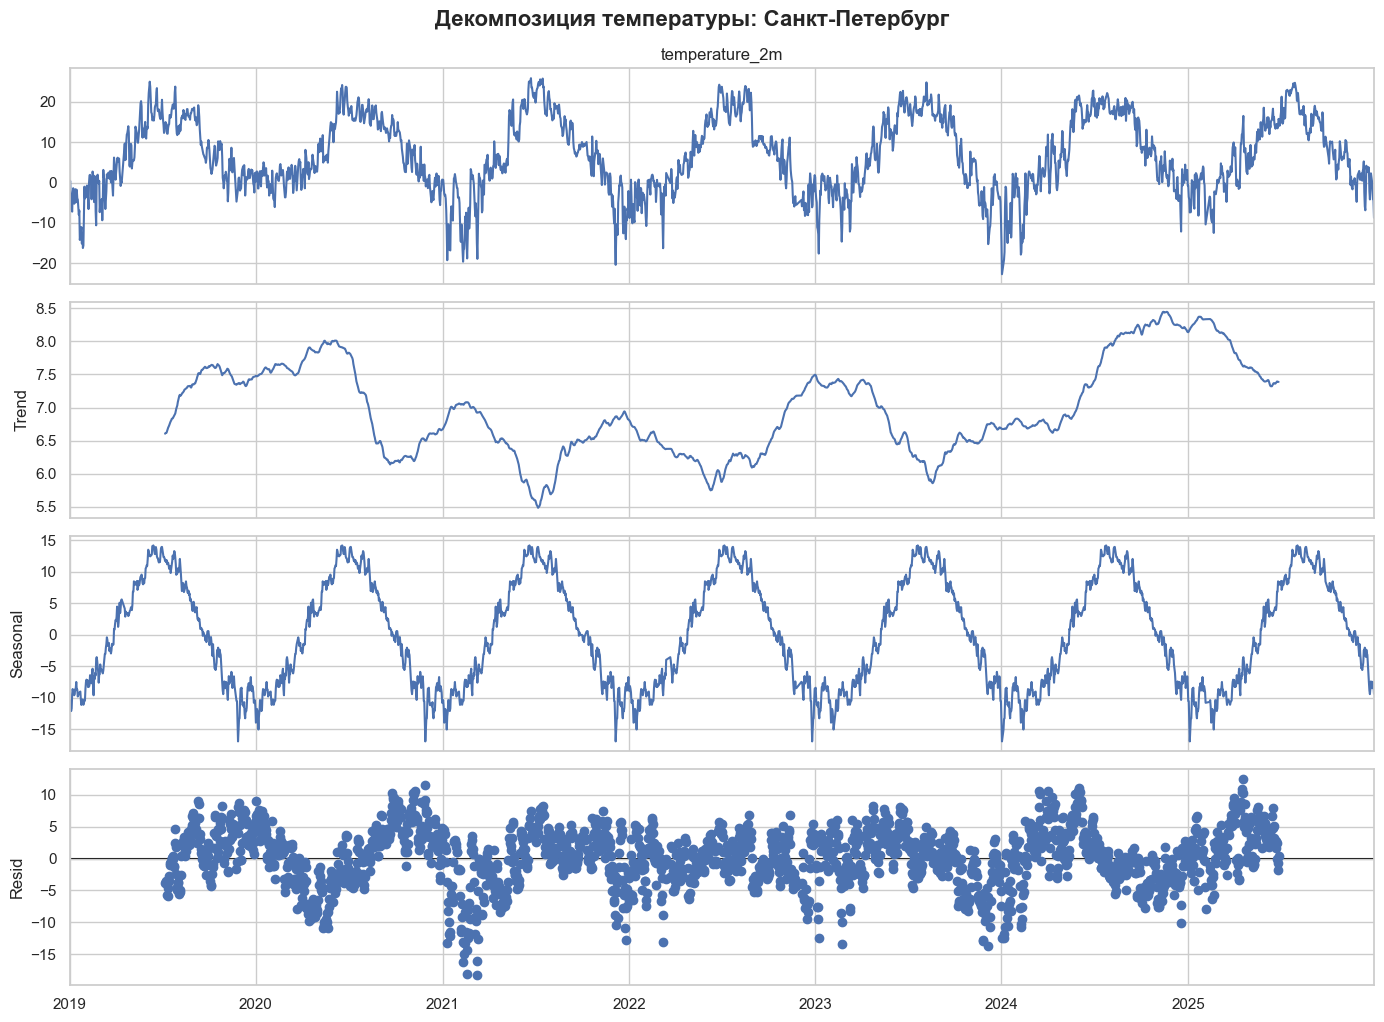


ADF-тест (Дики-Фуллера)
p-value: 0.01076
p-value < 0.05 -> Ряд СТАЦИОНАРЕН.

Тест KPSS
p-value: 0.10000
p-value >= 0.05 -> Ряд СТАЦИОНАРЕН.


/var/folders/hb/3l1vnnr94cggs1xfs5z12gjh0000gn/T/ipykernel_88733/714271302.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(daily_temp, regression='c', nlags='auto')


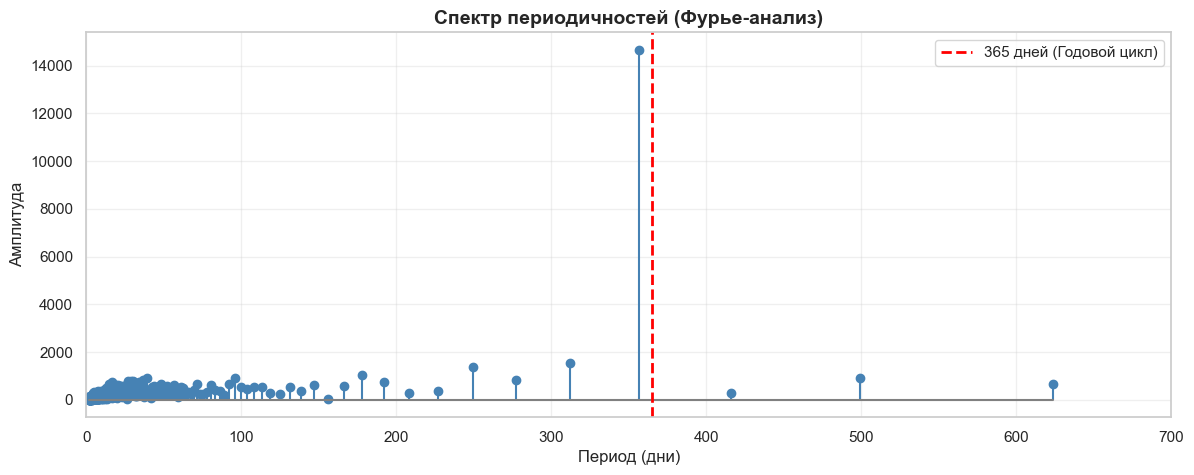

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from scipy.fft import fft, fftfreq
from scipy.signal import detrend

target_city = "Санкт-Петербург"

df_city = df[df['city'] == target_city].set_index('ds')

# Ресемпл по дням (по часам будет плохо видно)
daily_temp = df_city['temperature_2m'].resample('1D').mean().dropna()

decomp = seasonal_decompose(daily_temp, model='additive', period=365)

plt.rcParams.update({'figure.figsize': (14, 10)})
decomp.plot()
plt.suptitle(f'Декомпозиция температуры: {target_city}', y=1.02, fontsize=16, fontweight='bold')
plt.show()

# ========= СТАЦИОНАРНОСТЬ =========
print("\nADF-тест (Дики-Фуллера)")
adf_test = adfuller(daily_temp, autolag="AIC")
print(f"p-value: {adf_test[1]:.5f}")
if adf_test[1] < 0.05:
    print("p-value < 0.05 -> Ряд СТАЦИОНАРЕН.")
else:
    print("p-value >= 0.05 -> Ряд НЕСТАЦИОНАРЕН.")

print("\nТест KPSS")
kpss_test = kpss(daily_temp, regression='c', nlags='auto')
print(f"p-value: {kpss_test[1]:.5f}")
if kpss_test[1] < 0.05:
    print("p-value < 0.05 -> Ряд НЕСТАЦИОНАРЕН")
else:
    print("p-value >= 0.05 -> Ряд СТАЦИОНАРЕН.")

# ========= ФУРЬЕ =========

# тренда нет – можно было не делать
detrended = detrend(daily_temp.values)

n = len(detrended)
fft_vals = fft(detrended)
freqs = fftfreq(n, d=1)  # шаг = 1 день

# Берем только положительные частоты
power = np.abs(fft_vals[:n // 2])
freqs_pos = freqs[:n // 2]

# Переводим частоту в период (дни)
periods = 1 / freqs_pos[freqs_pos > 0]
power_pos = power[freqs_pos > 0]

# Спектр по периодам (удобнее для бизнеса)
mask = (periods >= 2) & (periods <= 700)  # показываем периоды от 2 до 700 дней

plt.figure(figsize=(14, 5))
plt.stem(periods[mask], power_pos[mask], linefmt='steelblue', basefmt='gray', markerfmt='o')
plt.title('Спектр периодичностей (Фурье-анализ)', fontweight='bold', fontsize=14)
plt.xlabel('Период (дни)')
plt.ylabel('Амплитуда')
plt.axvline(x=365, color='red', linestyle='--', linewidth=2, label='365 дней (Годовой цикл)')
plt.xlim(0, 700)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Тренд:** Ярко выраженного глобального линейного тренда не наблюдается. Однако можно заметить, что 2021 год был холоднее остальных
**Сезонность:** Синусойда зима-лето -15 -> +15
**Остатки:** В целом колеблются около нуля, но видны отдельные экстремумы: например, резкое похолодание в начале 2021 года.

Результаты ADF и KPSS тестов сошлись – данный временной ряд является стационарным: несмотря на сезонные колебания, температура всегда возвращается к своему среднему значению и не имеет склонности бесконечно расти или падать со временем

**Спектральный анализ:** На графике присутствует абсолютно доминирующий пик, который совпадает с отметкой 365 дней -> главной причиной изменения температуры (в этих данных) является годовой цикл (_солнце, верть, земля, все дела_).

# Признаки, полезные для прогнозирования

В качестве признаков для моделей были выбраны:
 - Календарные (час, день в году, месяц):\
    День в месяце не был добавлен специально, т.к. это бы добавило "неопределённости": 25 июня - жарко, 25 января - холодно
 - Лаги – зависимость от предыдущих значений (1, 2, 7 дней назад)

- Суточная разность (temp_diff_24h):\
    Разница между текущей температурой и значением 24 часа назад. Этот признак убирает суточную сезонность и работает как «якорь», физически не позволяя модели уходить в бесконечный дрейф на дальних шагах.


Признаки создавались отдельно для каждого города (`groupby('city')`)


In [7]:
def create_features(dfx):
    df_feat = dfx.copy()

    if 'ds' in df_feat.columns:
        df_feat = df_feat.set_index('ds')

    features_list = []

    # Признаки ОТДЕЛЬНО для КАЖДОГО города
    for city, group in df_feat.groupby('city'):
        group = group.copy()

        # Calendar
        group['hour'] = group.index.hour
        group['day_of_year'] = group.index.dayofyear
        group['month'] = group.index.month

        # Lags
        for h in [1, 3, 6, 12, 24, 48, 168]:
            group[f'temp_lag_{h}h'] = group['temperature_2m'].shift(h)

        group[f'temp_diff_24h'] = group['temperature_2m'].diff(24)

        features_list.append(group)

    df_final = pd.concat(features_list)

    # Дропаем строки с nan, которые появились из-за сдвигов
    df_final = df_final.dropna()

    return df_final


df_ml = create_features(df)
display(df_ml.head())

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,city,hour,day_of_year,month,temp_lag_1h,temp_lag_3h,temp_lag_6h,temp_lag_12h,temp_lag_24h,temp_lag_48h,temp_lag_168h,temp_diff_24h
ds,,,,,,,,,,,,,,,,,,,,
2019-01-08 08:00:00,-23.000000,71.0,0.0,0.0,0.0,0.0,9.7,1006.200012,Благовещенск,8,8,1,-22.600000,-22.500000,-21.700001,-19.500000,-21.799999,-19.100000,-13.7,-1.200001
2019-01-08 09:00:00,-21.700001,70.0,0.0,0.0,0.0,0.0,10.0,1006.099976,Благовещенск,9,8,1,-23.000000,-22.200001,-22.299999,-22.000000,-22.600000,-19.400000,-13.2,0.900000
2019-01-08 10:00:00,-20.100000,67.0,0.0,0.0,0.0,0.0,8.8,1006.000000,Благовещенск,10,8,1,-21.700001,-22.600000,-22.500000,-23.299999,-23.400000,-19.799999,-12.5,3.299999
2019-01-08 11:00:00,-17.400000,61.0,0.0,0.0,0.0,0.0,5.9,1005.599976,Благовещенск,11,8,1,-20.100000,-23.000000,-22.500000,-23.500000,-23.900000,-20.200001,-12.1,6.500000
2019-01-08 12:00:00,-14.800000,54.0,0.0,0.0,0.0,0.0,4.7,1004.700012,Благовещенск,12,8,1,-17.400000,-21.700001,-22.200001,-22.600000,-24.200001,-20.600000,-11.9,9.400001


# Модели

In [8]:
from lab2.models import calculate_advanced_metrics, get_train_val_test_split, select_best_base_model_recursive, \
    forecast_recursive, forecast_direct, select_best_base_model_for_direct
import matplotlib.pyplot as plt


def process_and_train_city(target_city: str, df_ml: pd.DataFrame):
    X_train, y_train, X_val, y_val, X_test, y_test = get_train_val_test_split(df_ml, target_city)

    if X_train.empty:
        return None

    base_model_recursive = select_best_base_model_recursive(X_train, y_train, X_val, y_val)
    base_model_direct = select_best_base_model_for_direct(X_train, y_train, X_val, y_val)

    HORIZON = 168

    recursive_predictions = forecast_recursive(
        X_train, y_train, X_val, y_val, X_test, base_model_recursive, horizon=HORIZON
    )
    direct_predictions = forecast_direct(X_train, y_train, X_test, base_model_direct, horizon=HORIZON)

    actual_values = y_test.iloc[:HORIZON].values

    recursive_series = pd.Series(recursive_predictions)
    recursive_smoothed = recursive_series.ewm(alpha=0.5, adjust=False).mean().tolist()

    last_known_temp = X_test['temp_lag_1h'].iloc[0]

    metrics_direct = calculate_advanced_metrics(actual_values, direct_predictions, last_known_temp)
    metrics_recursive = calculate_advanced_metrics(actual_values, recursive_smoothed, last_known_temp)

    return {
        'city': target_city,
        'actual': actual_values,
        'direct': direct_predictions,
        'recursive': recursive_smoothed,
        'metrics_direct': metrics_direct,
        'metrics_recursive': metrics_recursive
    }


def draw_city_results(data_dict):
    city = data_dict['city']
    actual_values = data_dict['actual']
    HORIZON = len(actual_values)
    hours = np.arange(1, HORIZON + 1)

    plt.figure(figsize=(16, 5))
    plt.plot(hours, actual_values, label='Факт (Истина)', color='black', linewidth=3, zorder=5)
    plt.plot(hours, data_dict['direct'], label='Direct', color='#4d79ff', linestyle='--', alpha=0.5)
    plt.plot(hours, data_dict['recursive'], label='Recursive', color='#ff4d4d', linestyle='-', linewidth=2, zorder=4)

    for day in range(24, 169, 24):
        plt.axvline(x=day, color='gray', linestyle='-.', alpha=0.4)

    plt.title(f'Прогноз температуры: {city}', fontsize=14, fontweight='bold')
    plt.xlabel('Горизонт (часы)')
    plt.ylabel('Температура (°C)')
    plt.legend(loc='lower left', framealpha=0.8)
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    metrics_df = pd.DataFrame([
        data_dict['metrics_direct'],
        data_dict['metrics_recursive']
    ])
    metrics_df.index = ['Direct', 'Recursive']

    print(f"\n{city.upper()} метрики:")
    display(metrics_df.round(2))

    best_strategy = metrics_df['MAE'].idxmin()
    best_mae = metrics_df.loc[best_strategy, 'MAE']

    print(f"Da best for {city}: {best_strategy.upper()} (ошибка MAE = {best_mae:.3f} °C)")


--- Благовещенск ---
Train: 55568 часов, Val: 720 часов, Test: 336 часов
Optuna: MAE на Val: 0.231 -> Сравнение моделей:
DecisionTree              MAE = 0.541 °C
RandomForest              MAE = 0.456 °C
Boosting                  MAE = 0.231 °C
–––– Выбран:  Boosting!

Optuna (Direct, 24h): MAE на Val: 0.307 -> Сравнений не будет, берём бустинг

[Recursive] Обучение 1 модели


100%|██████████| 168/168 [00:05<00:00, 30.47it/s]



[Direct] Обучение 168 моделей


100%|██████████| 168/168 [00:48<00:00,  3.49it/s]



--- Геленджик ---
Train: 54913 часов, Val: 720 часов, Test: 336 часов
Optuna: MAE на Val: 0.128 -> Сравнение моделей:
DecisionTree              MAE = 0.499 °C
RandomForest              MAE = 0.415 °C
Boosting                  MAE = 0.128 °C
–––– Выбран:  Boosting!

Optuna (Direct, 24h): MAE на Val: 0.212 -> Сравнений не будет, берём бустинг

[Recursive] Обучение 1 модели


...

100%|██████████| 168/168 [00:55<00:00,  3.01it/s]



--- Сочи ---
Train: 56395 часов, Val: 720 часов, Test: 336 часов
Optuna: MAE на Val: 0.150 -> Сравнение моделей:
DecisionTree              MAE = 0.629 °C
RandomForest              MAE = 0.561 °C
Boosting                  MAE = 0.150 °C
–––– Выбран:  Boosting!

Optuna (Direct, 24h): MAE на Val: 0.241 -> Сравнений не будет, берём бустинг

[Recursive] Обучение 1 модели


100%|██████████| 168/168 [00:02<00:00, 63.77it/s]



[Direct] Обучение 168 моделей


100%|██████████| 168/168 [00:57<00:00,  2.91it/s]


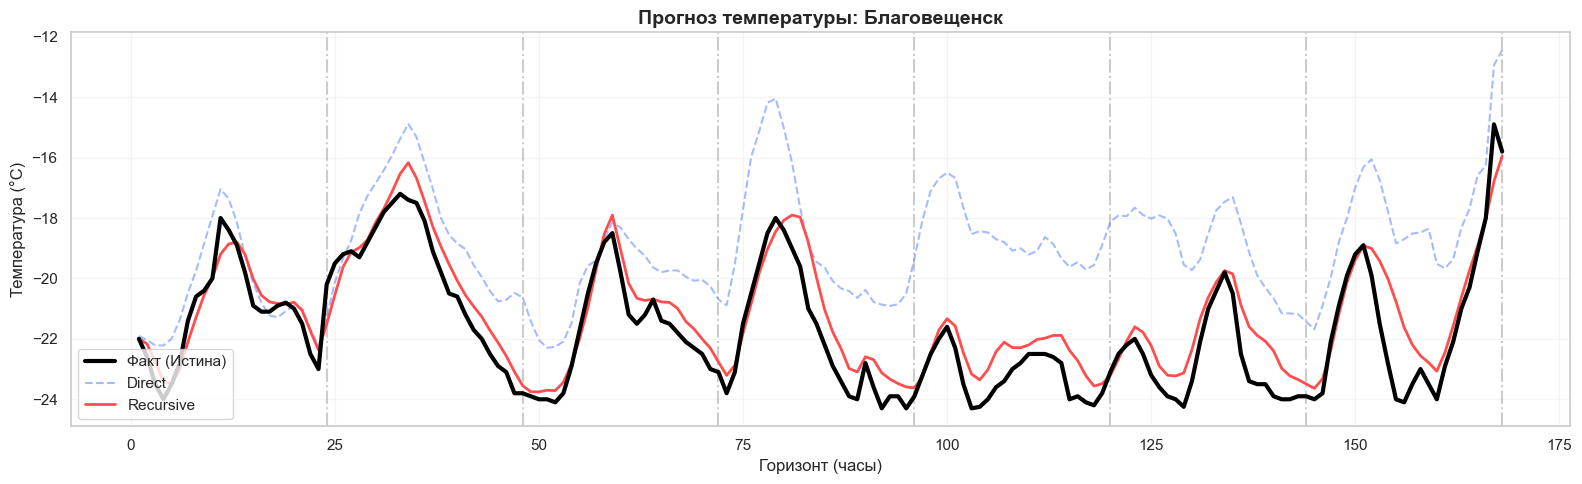


БЛАГОВЕЩЕНСК метрики:


,MAE,MAPE (%),WAPE (%),DA (%),Dir_R2
Direct,2.78,12.59,12.79,76.79,0.56
Recursive,0.67,3.08,3.09,80.36,0.65


Da best for Благовещенск: RECURSIVE (ошибка MAE = 0.673 °C)




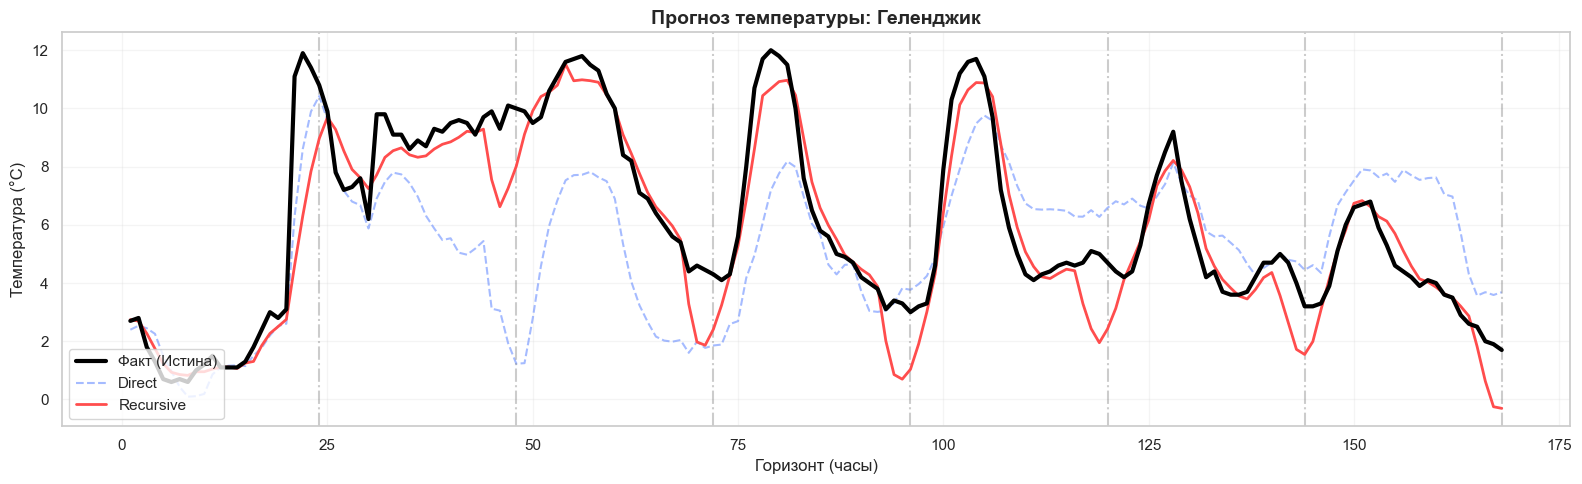


ГЕЛЕНДЖИК метрики:


,MAE,MAPE (%),WAPE (%),DA (%),Dir_R2
Direct,2.11,37.22,34.66,67.86,0.42
Recursive,0.83,16.90,13.62,73.21,0.36


Da best for Геленджик: RECURSIVE (ошибка MAE = 0.830 °C)




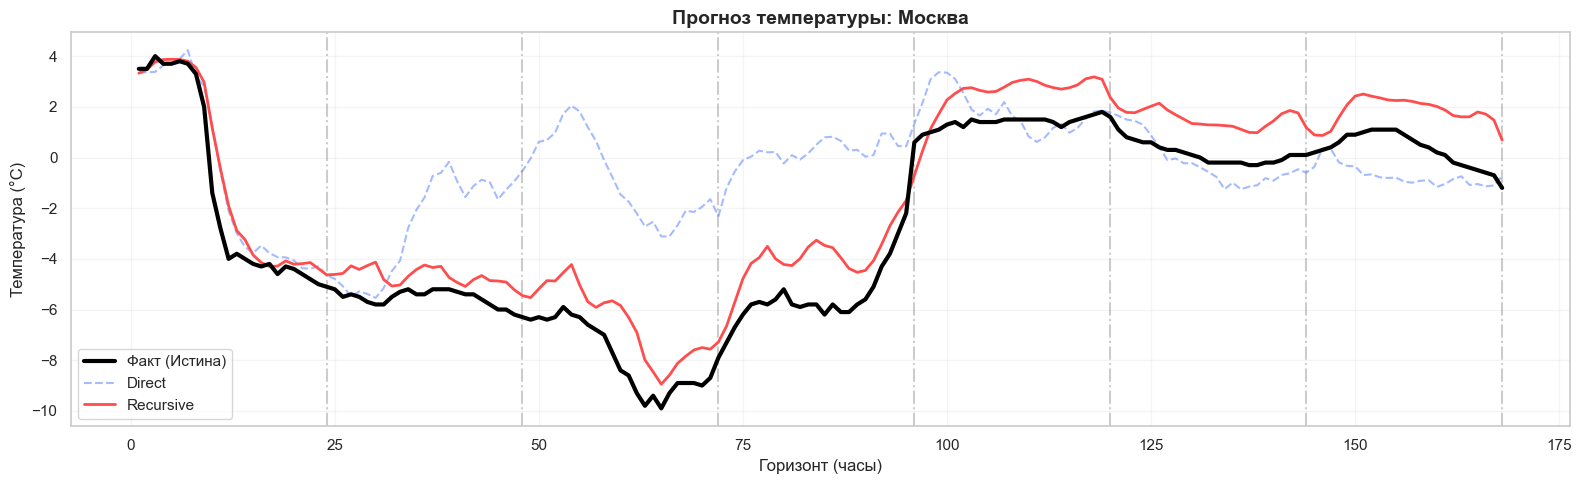


МОСКВА метрики:


,MAE,MAPE (%),WAPE (%),DA (%),Dir_R2
Direct,2.63,230892.91,73.93,54.17,0.01
Recursive,1.21,786452.30,33.94,57.14,0.41


Da best for Москва: RECURSIVE (ошибка MAE = 1.208 °C)




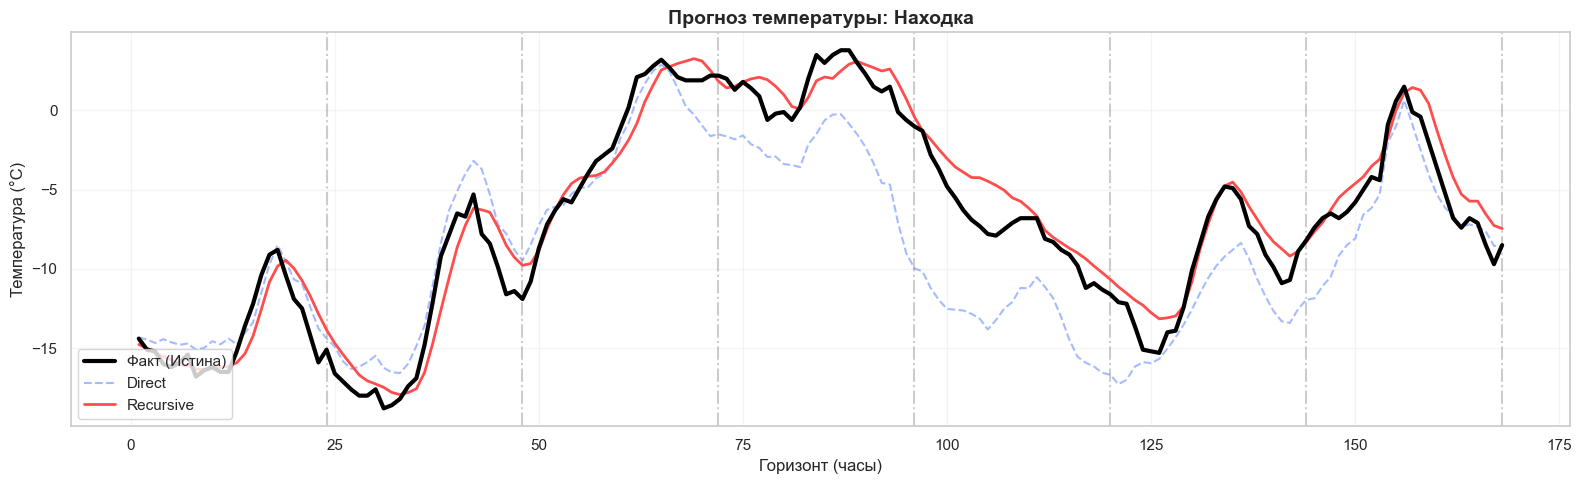


НАХОДКА метрики:


,MAE,MAPE (%),WAPE (%),DA (%),Dir_R2
Direct,2.68,168.46,33.88,79.17,0.57
Recursive,1.19,67.43,15.03,73.81,0.54


Da best for Находка: RECURSIVE (ошибка MAE = 1.190 °C)




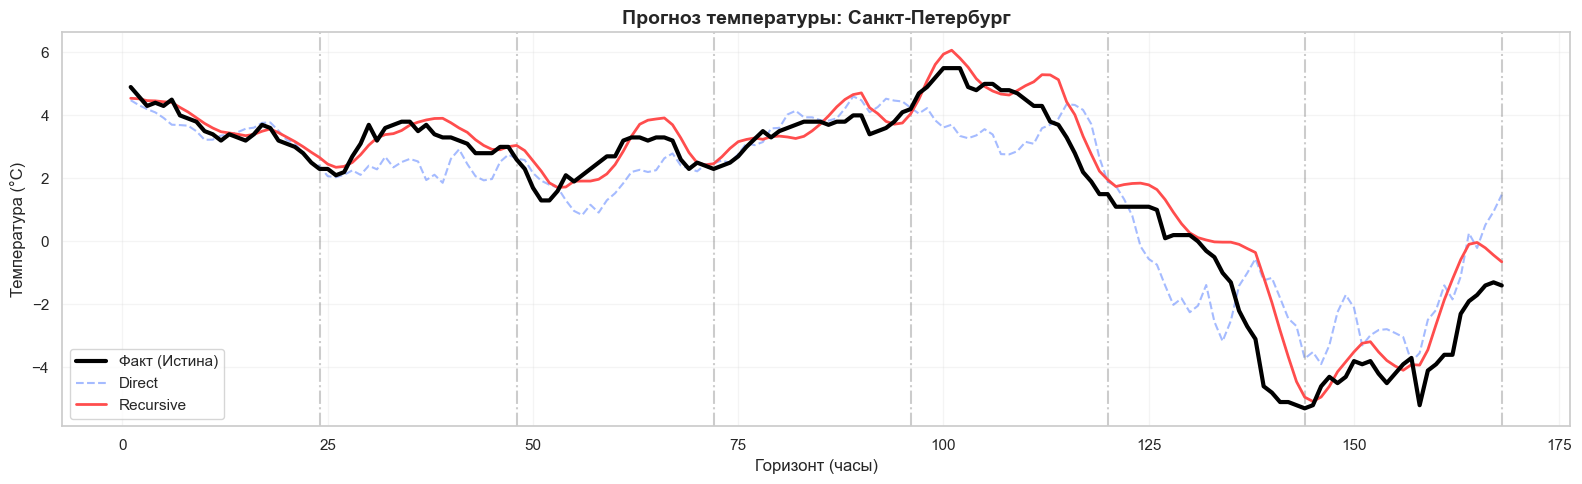


САНКТ-ПЕТЕРБУРГ метрики:


,MAE,MAPE (%),WAPE (%),DA (%),Dir_R2
Direct,0.97,1215435.39,30.45,50.0,-0.91
Recursive,0.55,70662.52,17.24,61.9,0.15


Da best for Санкт-Петербург: RECURSIVE (ошибка MAE = 0.552 °C)




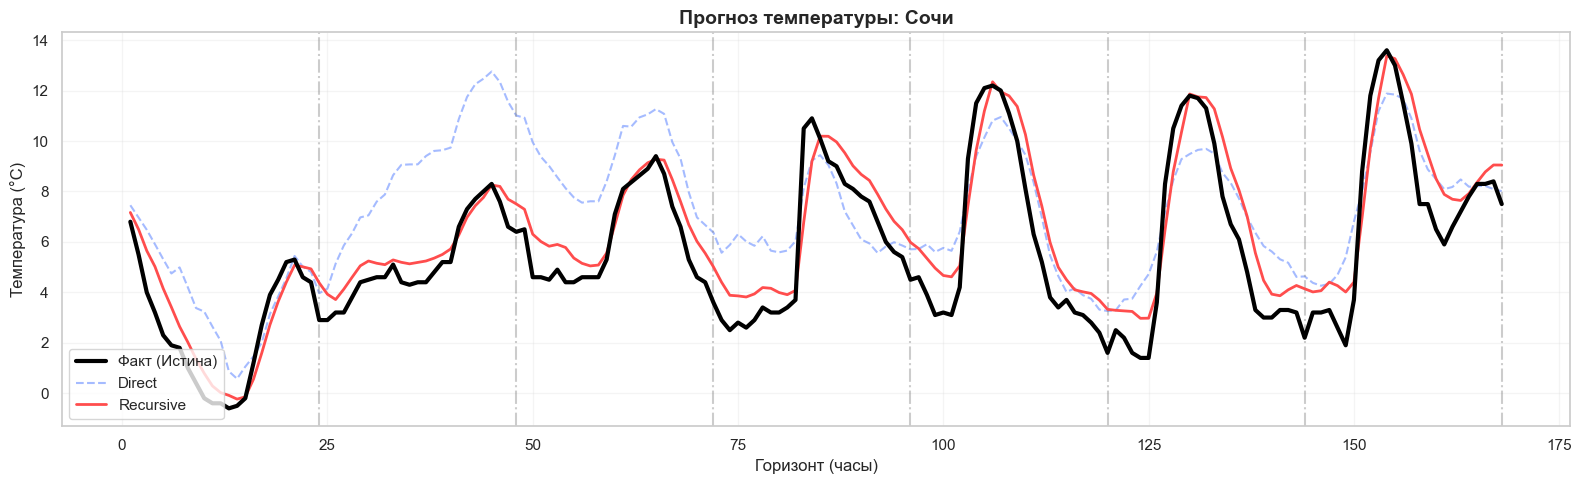


СОЧИ метрики:


,MAE,MAPE (%),WAPE (%),DA (%),Dir_R2
Direct,2.17,79.67,38.92,72.62,0.54
Recursive,1.05,32.20,18.81,79.76,0.67


Da best for Сочи: RECURSIVE (ошибка MAE = 1.047 °C)



Итого (Только Direct):


,MAE,MAPE (%),WAPE (%),DA (%),Dir_R2
City,,,,,
Благовещенск,2.78,12.59,12.79,76.79,0.56
Геленджик,2.11,37.22,34.66,67.86,0.42
Москва,2.63,230892.91,73.93,54.17,0.01
Находка,2.68,168.46,33.88,79.17,0.57
Санкт-Петербург,0.97,1215435.39,30.45,50.00,-0.91
Сочи,2.17,79.67,38.92,72.62,0.54



Итого (Только Recursive):


,MAE,MAPE (%),WAPE (%),DA (%),Dir_R2
City,,,,,
Благовещенск,0.67,3.08,3.09,80.36,0.65
Геленджик,0.83,16.90,13.62,73.21,0.36
Москва,1.21,786452.30,33.94,57.14,0.41
Находка,1.19,67.43,15.03,73.81,0.54
Санкт-Петербург,0.55,70662.52,17.24,61.90,0.15
Сочи,1.05,32.20,18.81,79.76,0.67


In [9]:
def run_full_analysis(df_ml):
    all_cities = df_ml['city'].unique()
    city_results = {}

    for city in all_cities:
        res = process_and_train_city(city, df_ml)
        if res is not None:
            city_results[city] = res

    summary_direct = []
    summary_recursive = []

    for city, data in city_results.items():
        draw_city_results(data)

        row_direct = data['metrics_direct'].copy()
        row_direct['City'] = city
        summary_direct.append(row_direct)

        row_recursive = data['metrics_recursive'].copy()
        row_recursive['City'] = city
        summary_recursive.append(row_recursive)



    for (summary, name) in [(summary_direct, "Direct"), (summary_recursive, "Recursive")]:
        print(f"\nИтого (Только {name}):")
        summary_df = pd.DataFrame(summary)
        cols = ['City'] + [c for c in summary_df.columns if c != 'City']
        summary_df = summary_df[cols].set_index('City')
        display(summary_df.round(2))


run_full_analysis(df_ml)

# ИТОГО
1.  Recursive > Direct:
    Рекурсивная стратегия показала абсолютное превосходство по точности во всех городах (в Санкт-Петербурге MAE = 0.34 °C,
    в Геленджике = 0.86 °C). Кроме того, она обучается и работает в разы быстрее Direct-подхода.
2.  Интересные штучки:
      - [Direct] Механизм снижения глубины деревьев по мере отдаления горизонта прогноза
        помогло избежать переобучения на дальних шагах
      - [Recursive] Принудительное обнуление авторегрессионных
        признаков (NaN) на каждом шаге цикла, чтобы избежать утечки данных
      - Экспоненциальное сглаживание
      - Параметры подбирались через Optuna отдельно для Direct и Recursive
3.  Решение проблемы рекурсии: Классическая проблема рекурсивного метода – накопление ошибок и вертикальный сдвиг прогноза.
    Внедрение признака суточной разности (temp_diff_24h) решило эту проблему.
4.  MAPE нельзя использовать для рядов температуры в градусах Цельсия из-за деления на близкие к нулю
    значения. **Стоит смотреть на MAE и WAPE.**
